# Feladatleírás

### Motiváció

Ha az embernek van ingatlanja, és szeretné is kiadni, sokszor eshet abba a dilemmába,
hogy mennyit is érhet az ingatlanja valójában. A most építendő modellek segítségével jól
meg lehetne becsülni az elhelyezkedési, méretbeli és egyéb paraméterek alapján egy lakás
bérlésének éves díját, ami sokat segíthet leendő főbérlőknek, hogy a trend szerinti árak
közül hogyan válasszanak, valamint az is meg tudjuk a végére mondani, hogy milyen dolgok
befolyásolják legjobban az ingatlan bérlési árakat.

### Módszer

Az adathalmaz az USA ingatlanbérlési piacáról tartalmaz információkat. Az adathalmazt szűrni kell a: a lényegtelen, vagy nehezen felhasználható feature-öket el kell dobni, a hiányzó értékeket esetenként pótolni kell, és esetleges dimneziócsökkentést is el lehet végezni. A végső adathalmazból a bérlési ár (price) mezőt kell majd regresszióval kiszámolni, az egyéb, megtisztított bemeneti paraméterekkel. A tanító és tesztelő részek 75-25 arányban lesznek elosztva a teljes adathalmazon.

### Adathalmaz

Elérhetősége: https://archive.ics.uci.edu/dataset/555/apartment+for+rent+classified
Az adathalmaz nem tölthető le, egy python script segítségével lett csv-vé konvertálva.

Csak az USA-ban található ingatlan bérbeadási hirdetéseket tartalmazza, több oldalról/szolgáltatótól összeszedve.
10 valamint 100 ezer rekordos verziók is elérhetőek. A project során a 100 ezres adathalmaz lesz felhasználva.

### Feature-ök:
1. category: hirdetés kategóriája, string
2. title: hirdetés címe, string
3. body: hirdetés szövege, string
4. amenities: különleges felszereltségek listája, string, sok hiányzó érték
5. bathrooms: fürdők száma
6. bedrooms: hálószobák száma
7. currency: pénznem, minden értelmes értéket tartalmazó mező USD
8. fee: díj (nincs egyéb leírás, hogy mié), integer vagy igen/nem vagy hiányzó érték
9. has_photo: hirdetésben szereplő fotók kategóriája, van/nincs vagy csak “Thumbnail” vagy hiányzó érték
10.pets_allowed: milyen állatok megengedettek, string
11.price: ára, double, kiszámítandó érték
12.price_display: hirdetésben megjelenített ára, integer, egyezik a price-al
13.price_type: fizetési gyakoriság, “Monthly” vagy “Weekly” vagy hiányzó érték
14. square_feet: alapterület, integer hiányzó érték
15.address: cím, string
16.cityname: város neve, string
17. state: állam neve, string
18.latitude: szélességi fok, double
19.longitude: hosszúsági fok, double
20. source: honnan van a hirdetés, string, 26 egyedi érték
21. time: a hirdetés feladásának ideje, unix timestamp seconds formátumban megadva, 2018-2020 közötti értékek

# Előkészítés

In [107]:
# Csomag importálás, alapbeállítások

library(tidyverse, warn.conflicts=FALSE)
library(recipes, warn.conflicts=FALSE)
library(lubridate, warn.conflicts=FALSE)
library(corrplot, warn.conflicts=FALSE)
library(ggplot2, warn.conflicts=FALSE)
library(dplyr, warn.conflicts=FALSE)

options(repr.plot.width=10, repr.plot.height=7)

In [108]:
# Adatok beolvasása

df = read_csv("./../data/apartment_data.csv",
              col_types=list(
                  currency = col_factor(),
                  bathrooms = col_double(),
                  bedrooms = col_double(),
                  price_display = col_double(),
                  square_feet = col_double()
              ))

ERROR: Error in col_factor(): argument "domain" is missing, with no default


# Adatelemzés, tisztítás, ábrázolás

### Alapvető statisztikák

In [109]:
summary(df)

   category            title               body            amenities        
 Length:99826       Length:99826       Length:99826       Length:99826      
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
                                                                            
   bathrooms        bedrooms          currency         fee           
 Min.   :1.000   Min.   :0.000   USD      :99820   Length:99826      
 1st Qu.:1.000   1st Qu.:1.000   Cats,Dogs:    1   Class :character  
 Median :1.000   Median :2.000   1019     :    1   Mode  :character  
 Mean   :1.445   Mean   :1.728   NA's     :    4                     
 3rd Qu.:2.000   3rd Qu.:2.000    

In [110]:
# Vizsgálat a hibákra
glimpse(df)

head(problems(df), 20)

# Konklúzió
# Úgy néz ki sok hiba a soreltolódás miatt van, ezeket ki kell szűrni

Rows: 99,826
Columns: 21
$ category      <chr> "housing/rent/apartment", "housing/rent/apartment", "hou…
$ title         <chr> "One BR 507 & 509 Esplanade", "Three BR 146 Lochview Dri…
$ body          <chr> "This unit is located at 507 & 509 Esplanade, Redondo Be…
$ amenities     <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ bathrooms     <dbl> 1.0, 1.5, 2.0, 1.0, 1.0, 1.5, 2.0, 2.0, 1.0, 2.0, 2.5, 3…
$ bedrooms      <dbl> 1, 3, 3, 2, 1, 2, 2, 2, 2, 2, 3, 2, 2, 4, 3, 2, 1, 1, 3,…
$ currency      <fct> "USD", "USD", "USD", "USD", "USD", "USD", "USD", "USD", …
$ fee           <chr> "No", "No", "No", "No", "No", "No", "No", "No", "No", "N…
$ has_photo     <chr> "Thumbnail", "Thumbnail", "Thumbnail", "Thumbnail", "Thu…
$ pets_allowed  <chr> "Cats", "Cats,Dogs", NA, "Cats,Dogs", "Cats,Dogs", "Cats…
$ price         <dbl> 2195, 1250, 1395, 1600, 975, 1250, 1600, 1300, 795, 2150…
$ price_display <dbl> 2195, 1250, 1395, 1600, 975, 1250, 1600, 1300, 795, 2150…
$ price_type   

row,col,expected,actual,file
<int>,<int>,<chr>,<chr>,<chr>
6731,12,a double,"$1,560 Weekly",D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
7247,12,a double,$275 Monthly|Weekly,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
8810,5,a double,No,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
8810,6,a double,Thumbnail,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
8810,14,a double,NJ,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
33782,5,a double,No,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
33782,6,a double,Thumbnail,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
33782,14,a double,CA,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
50213,12,a double,"$8,500 Weekly",D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv


### Elsődleges adattisztítás

In [111]:
dfc = df

# Adatok eltolódása miatt keletkezett sorok szűrése
# Minden sorban USD-nek kellene szerepellnie, így használható szűrésre
dfc = filter(dfc, currency == "USD")

# NA-k feltöltése/szűrése
dfc = drop_na(dfc, price, price_display, square_feet, latitude, longitude)
dfc = replace_na(dfc,
                 list(bathrooms = median(df$bathrooms, na.rm=TRUE),
                 bedrooms = median(df$bedrooms, na.rm=TRUE),
                 pets_allowed = "None"))

# Nem értelmezett értékek szűrése
dfc = filter(dfc,
             grepl("housing/rent", category, fixed = TRUE), # csak kiadó lakások legyenek
             price_type %in% c("Monthly", "Weekly")) # csak diszkrét kategóriák legyenek

# Kategorizálás
dfc = mutate(dfc,
             category = factor(category),
             fee = factor(fee),
             has_photo = factor(has_photo),
             pets_allowed = fct_collapse(pets_allowed,
                Yes = c("Cats", "Cats,Dogs", "Cats,Dogs,None", "Dogs"),
                No = c("None")),
             price_type = factor(price_type),
             state = factor(state),
             cityname = factor(cityname),
             source = factor(source))

# Felhasználatlan/felesleges mezők szűrése
dfc = select(dfc, -title, -body, -currency, -address)

summary(dfc)

# price_type-ban 1 érték maradt, kivehető
dfc = select(dfc, -price_type)

                           category      amenities           bathrooms    
 housing/rent                  :    7   Length:99762       Min.   :1.000  
 housing/rent/apartment        :99701   Class :character   1st Qu.:1.000  
 housing/rent/commercial/retail:   42   Mode  :character   Median :1.000  
 housing/rent/condo            :    3                      Mean   :1.445  
 housing/rent/home             :    4                      3rd Qu.:2.000  
 housing/rent/other            :    1                      Max.   :9.000  
 housing/rent/short_term       :    4                                     
    bedrooms      fee            has_photo     pets_allowed     price      
 Min.   :0.000   No :99561   No       : 9256   Yes:39148    Min.   :  100  
 1st Qu.:1.000   Yes:  201   Thumbnail:34348   No :60614    1st Qu.: 1014  
 Median :2.000               Yes      :56158                Median : 1350  
 Mean   :1.728                                              Mean   : 1527  
 3rd Qu.:2.000      

### Kiugró értékek keresése

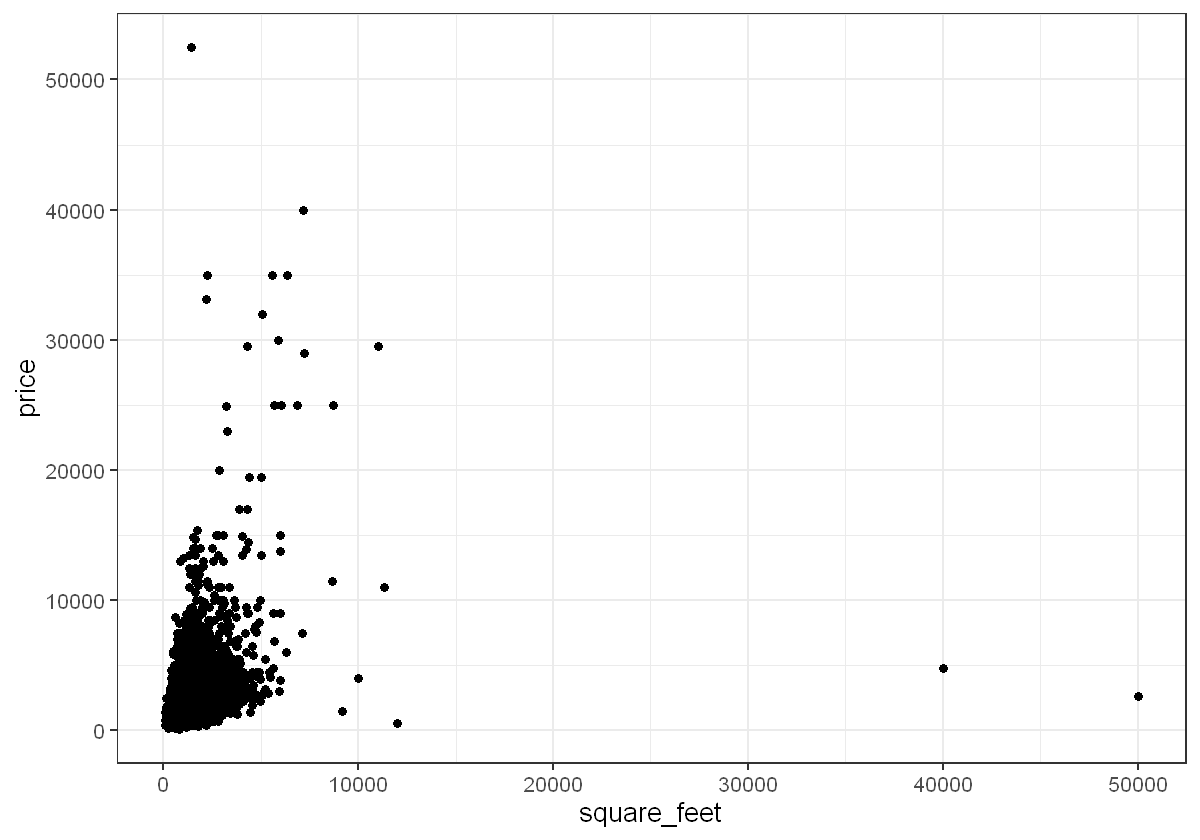

In [112]:
ggplot(data = dfc) +
geom_point(mapping = aes(x = square_feet, y = price)) +
theme_bw(base_size=16)

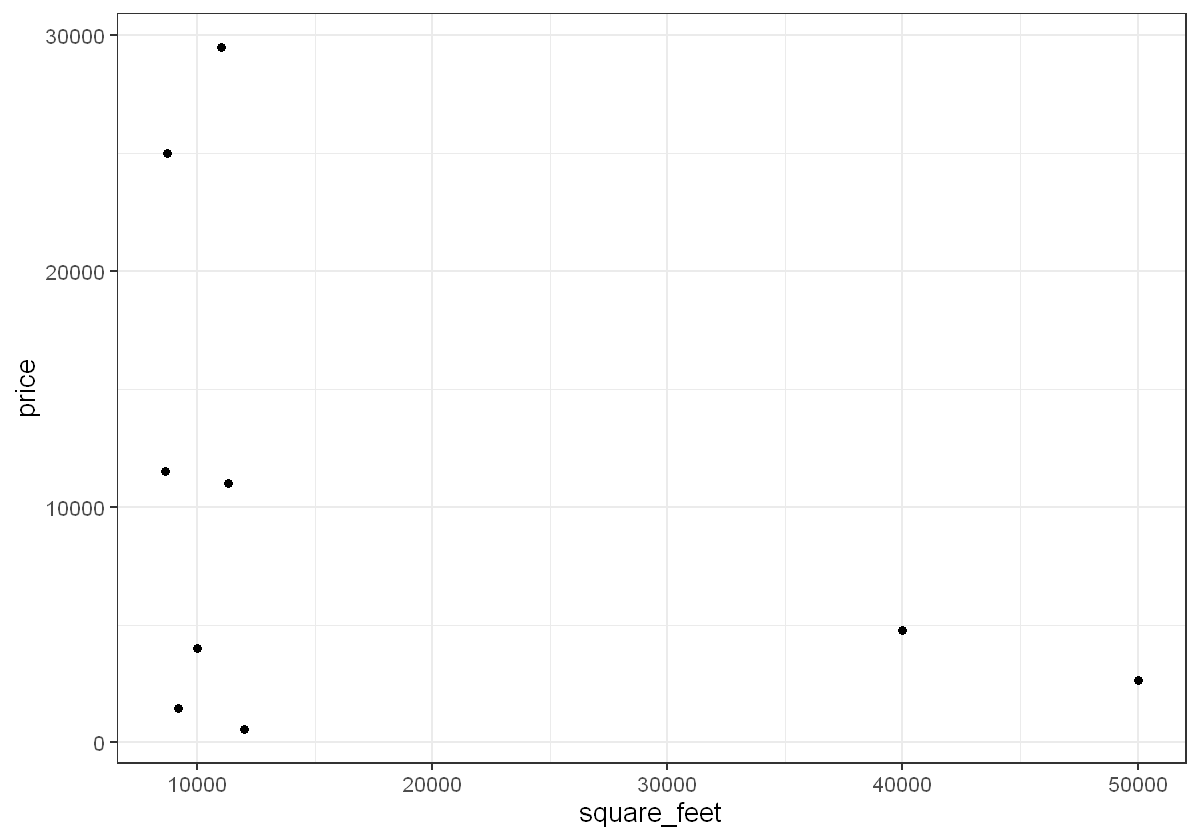

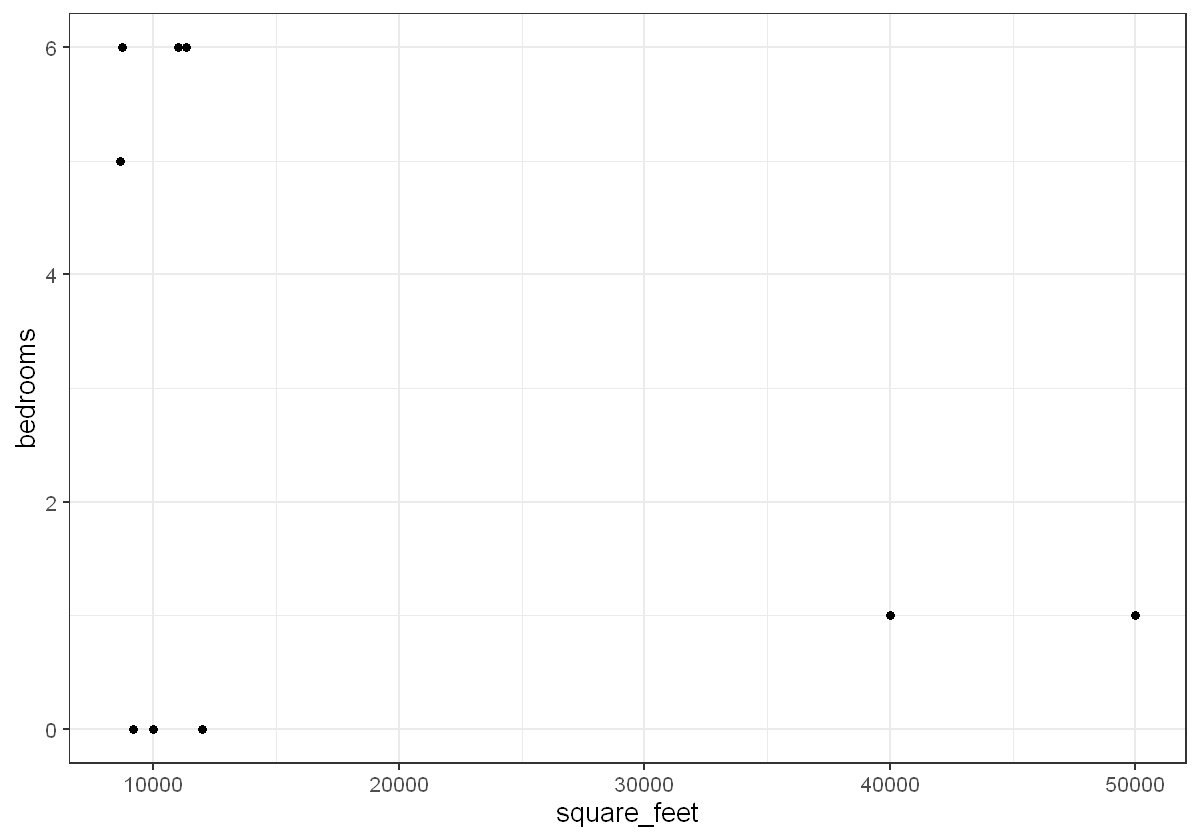

In [113]:
# A magas értékek vizsgálata
dfc %>%
filter(square_feet > 8000) %>%
ggplot() +
geom_point(mapping = aes(x = square_feet, y = price)) +
theme_bw(base_size=16)

dfc %>%
filter(square_feet > 8000) %>%
ggplot() +
geom_point(mapping = aes(x = square_feet, y = bedrooms)) +
theme_bw(base_size=16)

Konklúzió:  
Nem feltétlenül irreális értékek. Lehetséges, hogy telkekről és nagy villákról van szó (10000ft^2 ~ 900m^2).

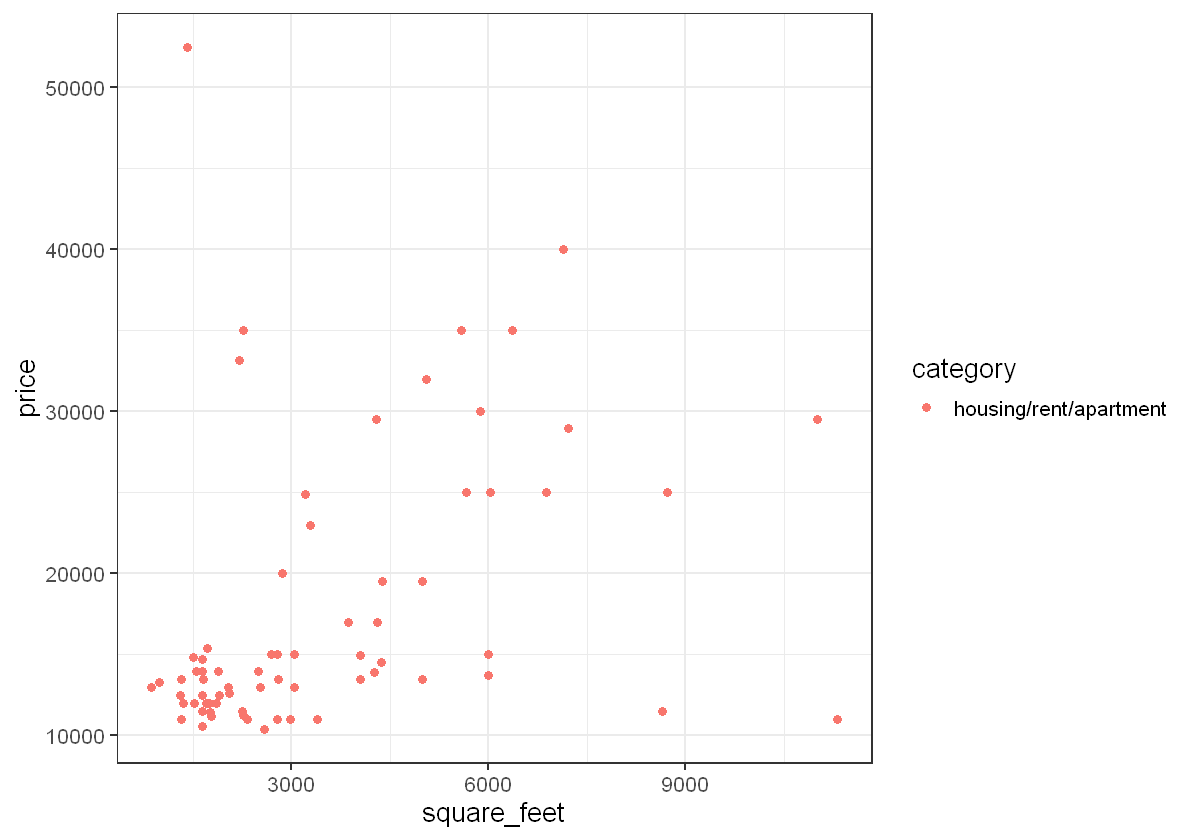

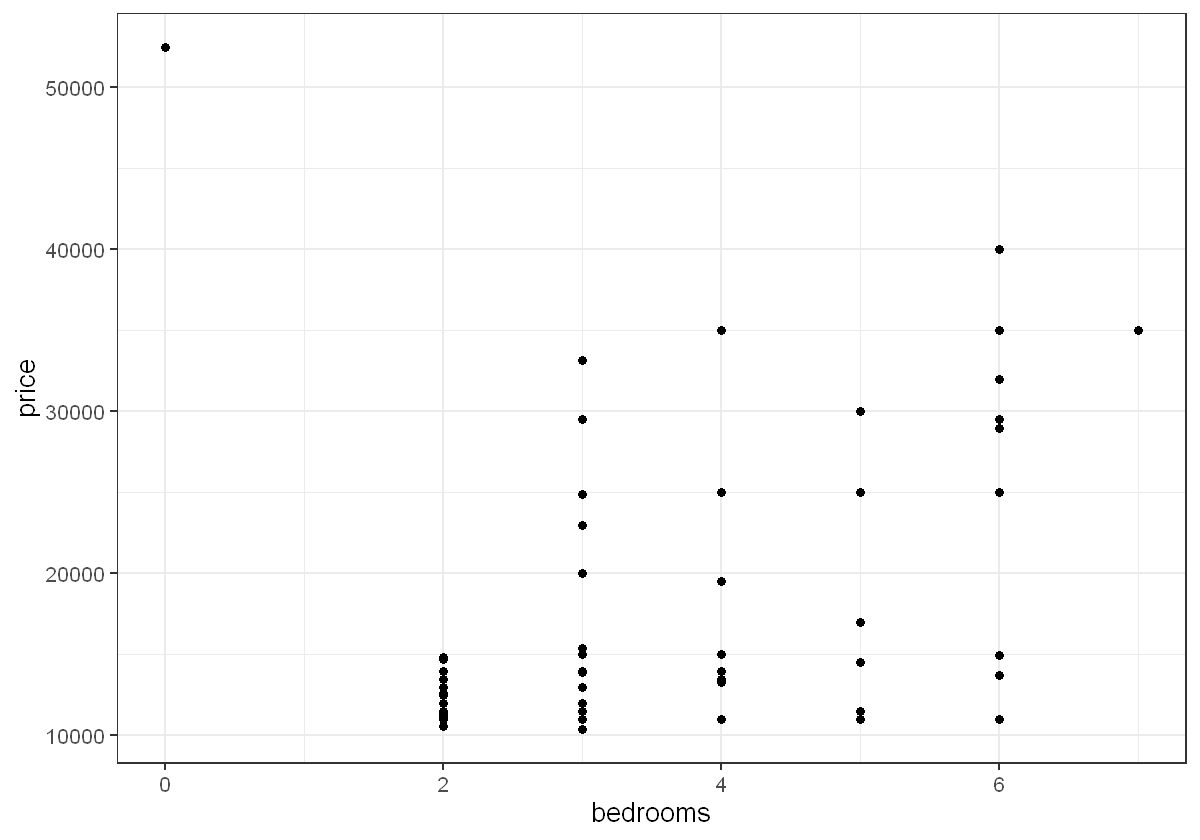

In [114]:
# A magas értékek vizsgálata
dfc %>%
filter(price > 10000) %>%
ggplot() +
geom_point(mapping = aes(x = square_feet, y = price, color = category)) +
theme_bw(base_size=16)

dfc %>%
filter(price > 10000) %>%
ggplot() +
geom_point(mapping = aes(x = bedrooms, y = price)) +
theme_bw(base_size=16)

Konklúzió:  
Lehetséges, hogy luxus villák is vannak hirdetve, így ezek nem feltétlenül irreális árak.  
A legdrágább, 50+ ezer dolláros háznak, azonban nem reális a 0 hálószoba száma. Mivel nem is ezzel helyettesítettünk, így ez egy valósan összeszedett érték az adathalmazban. Ezt az adatsort szűrjük ki.

In [115]:
dfc = filter(dfc, price < 50000)

### Adatelemzés

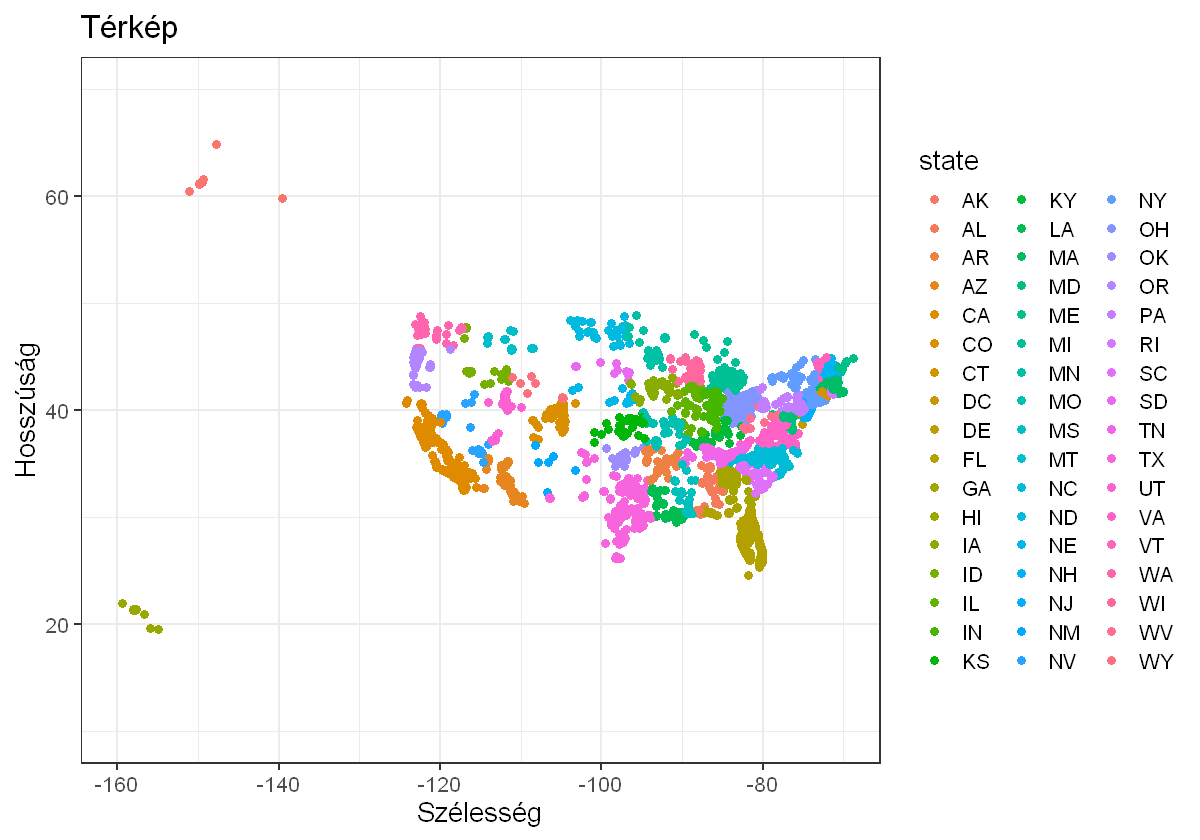

In [116]:
# Lat, long és state vizsgálat

dfc %>%
filter(!is.na(state)) %>%
ggplot() +
geom_point(mapping = aes(x = longitude, y = latitude, color = state)) +
coord_cartesian(xlim=c(-160,-70), ylim=c(10,70)) +
xlab("Szélesség") +
ylab("Hosszúság") +
ggtitle("Térkép") + 
theme_bw(base_size = 16)

Konklúzió:  
Nem látható kiugró érték, szépen látszanak az államok, és az USA térképe is kirajzolódik. Az vehető észre, hogy keleten, valamint a nyugati parton vannak a legtöbben a hirdetésre adott apartmanok, és középen, valamint Alaszkában szinte semennyi sincs. Ez vélhetően az időjárási tényezőknek, a munkalehetőségnek és a nagyvárosok elhelyezkedéseinek köszönhető.

In [117]:
# Amenities (felszereltség) kategória kezelése

dfc %>% 
filter(!is.na(amenities)) %>%
select(amenities) %>%
count(amenities) %>%
filter(n > 150) %>%
arrange(desc(n))

amenities,n
<chr>,<int>
Parking,6204
"Parking,Storage",2117
"Gym,Pool",1873
Pool,1483
"Gym,Parking,Pool",1191
"Parking,Pool",889
Washer Dryer,843
Patio/Deck,776
"Clubhouse,Gym,Pool",768


parking,storage,gym,pool,washer,patio,club,wood_floor,tv,tv_signal,dish_washer,fridge,luxury,gated,playground,fire,ac,tennis
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
43961,21670,37425,43642,26068,26581,19151,8903,4497,12542,16646,14947,211,8665,11358,14957,15835,8514


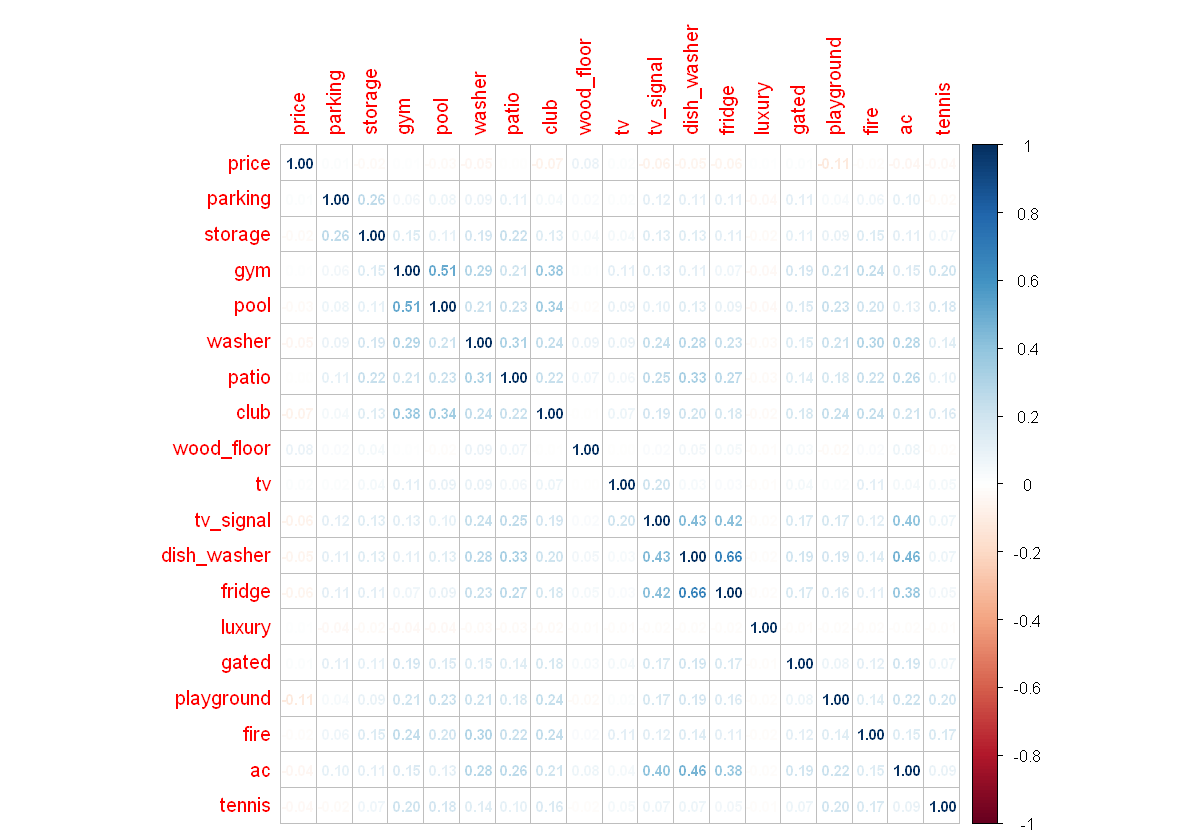

In [118]:
# Amenities (felszereltség) kategória kezelése 2.
# Vizsgáljuk a legtöbbet látott értékeket, hogy valójában hány helyen fordulnak elő

df_amenities = dfc %>%
select(price, amenities) %>%
mutate(parking     = as.numeric(grepl("Parking"           , amenities, fixed = TRUE)),
       storage     = as.numeric(grepl("Storage"           , amenities, fixed = TRUE)),
       gym         = as.numeric(grepl("Gym"               , amenities, fixed = TRUE)),
       pool        = as.numeric(grepl("Pool"              , amenities, fixed = TRUE)),
       washer      = as.numeric(grepl("Washer Dryer"      , amenities, fixed = TRUE)),
       patio       = as.numeric(grepl("Patio/Deck"        , amenities, fixed = TRUE)),
       club        = as.numeric(grepl("Clubhouse"         , amenities, fixed = TRUE)),
       wood_floor  = as.numeric(grepl("Wood Floors"       , amenities, fixed = TRUE)),
       tv          = as.numeric(grepl("TV"                , amenities, fixed = TRUE)),
       tv_signal   = as.numeric(grepl("Cable or Satellite", amenities, fixed = TRUE)),
       dish_washer = as.numeric(grepl("Dishwasher"        , amenities, fixed = TRUE)),
       fridge      = as.numeric(grepl("Refrigerator"      , amenities, fixed = TRUE)),
       luxury      = as.numeric(grepl("Luxury"            , amenities, fixed = TRUE)),
       gated       = as.numeric(grepl("Gated"             , amenities, fixed = TRUE)),
       playground  = as.numeric(grepl("Playground"        , amenities, fixed = TRUE)),
       fire        = as.numeric(grepl("Fireplace"         , amenities, fixed = TRUE)),
       ac          = as.numeric(grepl("AC"                , amenities, fixed = TRUE)),
       tennis      = as.numeric(grepl("Tennis"            , amenities, fixed = TRUE)),
) %>%
select(-amenities)

# Az érintett darabszámok vizsgálata
df_amenities_list = df_amenities %>%
select(-price) %>%
summarise_all(sum)

head(df_amenities_list)

# Korreláció vizsgálata a price-hoz képest
df_amenities %>%
cor() %>%
corrplot(method="number", number.cex=0.75)

Konklúzió:  
Szinte semmi korreláció nincs a felszereltség és az ár között. Ez meglehetősen furcsa, hiszen egy medence esetén azt várnánk, hogy mivel az egy luxus szolgáltatás, így drágább is lesz az ingatlan tőle.

In [119]:
# Amenities (felszereltség) kategória kezelése 3.
# A vizsgálat alapján a legjobb korrelációjú felszereltségek felhasználása

dfc = mutate(dfc,
       washer      = factor(grepl("Washer Dryer"      , amenities, fixed = TRUE)),
       club        = factor(grepl("Clubhouse"         , amenities, fixed = TRUE)),
       wood_floor  = factor(grepl("Wood Floors"       , amenities, fixed = TRUE)),
       tv_signal   = factor(grepl("Cable or Satellite", amenities, fixed = TRUE)),
       dish_washer = factor(grepl("Dishwasher"        , amenities, fixed = TRUE)),
       fridge      = factor(grepl("Refrigerator"      , amenities, fixed = TRUE)),
       playground  = factor(grepl("Playground"        , amenities, fixed = TRUE)))

dfc = mutate(dfc,
       washer      = fct_recode(washer     , "No" = "FALSE", "Yes" = "TRUE"),
       club        = fct_recode(club       , "No" = "FALSE", "Yes" = "TRUE"),
       wood_floor  = fct_recode(wood_floor , "No" = "FALSE", "Yes" = "TRUE"),
       tv_signal   = fct_recode(tv_signal  , "No" = "FALSE", "Yes" = "TRUE"),
       dish_washer = fct_recode(dish_washer, "No" = "FALSE", "Yes" = "TRUE"),
       fridge      = fct_recode(fridge     , "No" = "FALSE", "Yes" = "TRUE"),
       playground  = fct_recode(playground , "No" = "FALSE", "Yes" = "TRUE"))

dfc = select(dfc, -amenities)

glimpse(dfc)

Rows: 99,761
Columns: 22
$ category      <fct> housing/rent/apartment, housing/rent/apartment, housing/…
$ bathrooms     <dbl> 1.0, 1.5, 2.0, 1.0, 1.0, 1.5, 2.0, 2.0, 1.0, 2.0, 2.5, 3…
$ bedrooms      <dbl> 1, 3, 3, 2, 1, 2, 2, 2, 2, 2, 3, 2, 2, 4, 3, 2, 1, 1, 3,…
$ fee           <fct> No, No, No, No, No, No, No, No, No, No, No, No, No, No, …
$ has_photo     <fct> Thumbnail, Thumbnail, Thumbnail, Thumbnail, Thumbnail, T…
$ pets_allowed  <fct> Yes, Yes, No, Yes, Yes, Yes, No, Yes, Yes, No, No, No, N…
$ price         <dbl> 2195, 1250, 1395, 1600, 975, 1250, 1600, 1300, 795, 2150…
$ price_display <dbl> 2195, 1250, 1395, 1600, 975, 1250, 1600, 1300, 795, 2150…
$ square_feet   <dbl> 542, 1500, 1650, 820, 624, 965, 1120, 947, 600, 1005, 15…
$ cityname      <fct> Redondo Beach, Newport News, Raleigh, Vacaville, Albuque…
$ state         <fct> CA, VA, NC, CA, NM, NM, VA, CO, WV, CA, GA, MA, DC, AZ, …
$ latitude      <dbl> 33.8520, 37.0867, 35.8230, 38.3622, 35.1038, 35.1038, 37…
$ longitude    

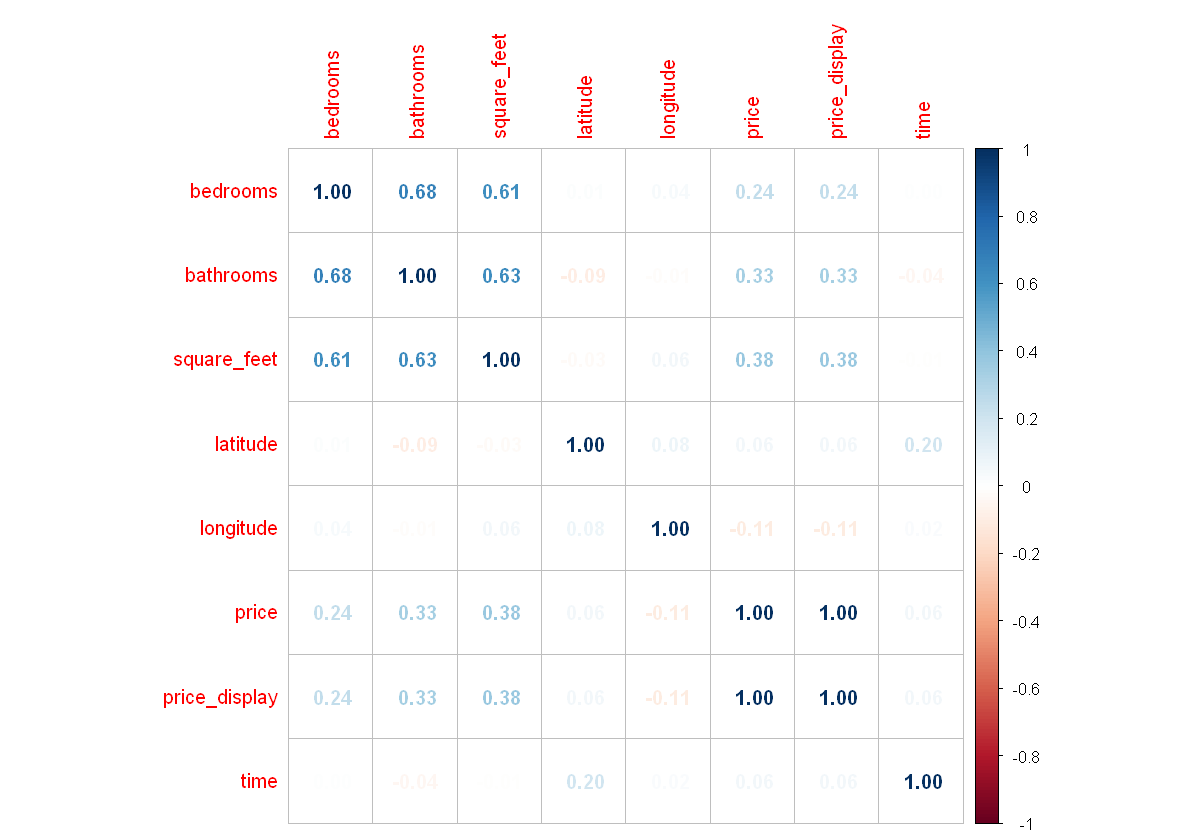

In [120]:
# Numerikus értékek korrelációs vizsgálata

sac_corr = dfc %>% 
select(bedrooms, bathrooms, square_feet, latitude, longitude, price, price_display, time)

mat = cor(sac_corr)
corrplot(mat, method="number")

Konklúzió:  
Vannak nagyobb korrelációk, pl. háló- és fürdőszobák számai között, de ilyen értékeknél még nem fognak problémát okozni a modelleknéz.  
A price_display egy az egyben a price-al azonos, így ezt el kell dobjuk, hogy legyen értelme a feladatnak.

In [121]:
dfc = select(dfc, -price_display)

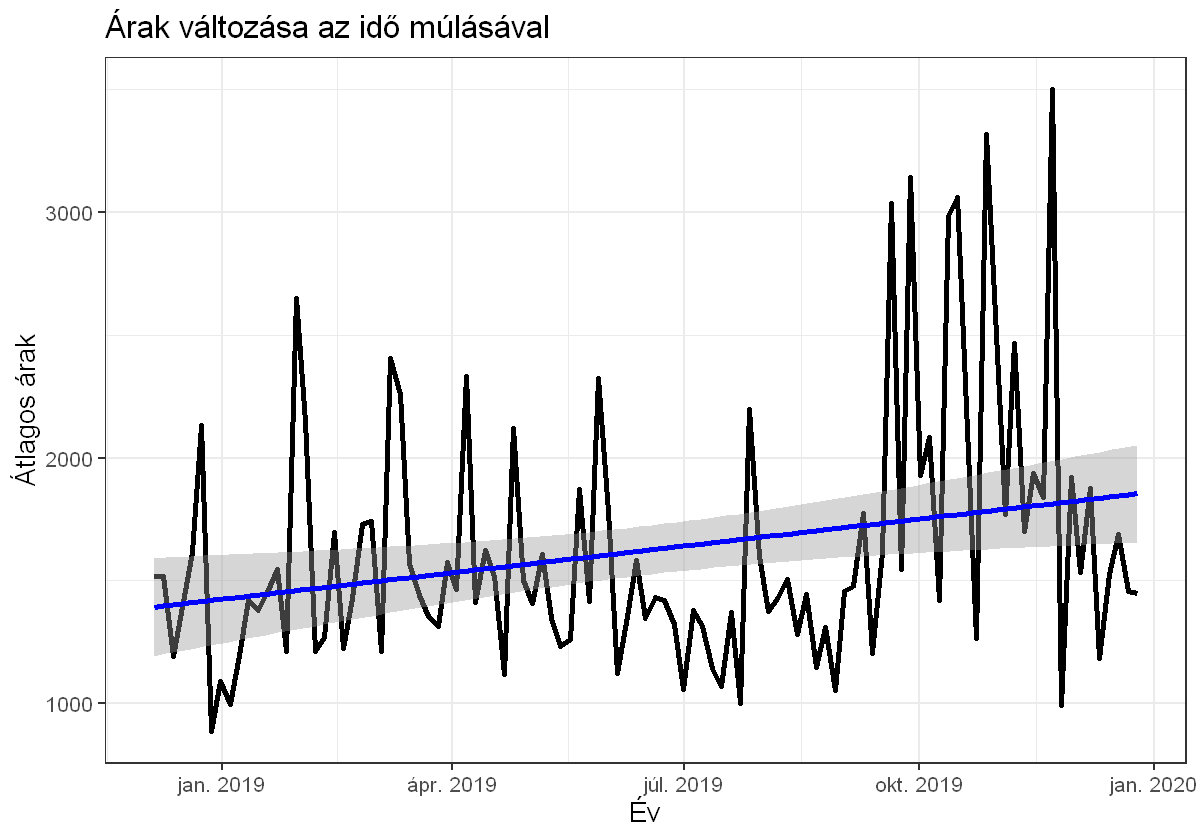

In [122]:
# Árak vizsgálata az idő múlásával

step = 320000

dfc %>%
group_by(tm = as.integer(time/step)) %>%
summarize(atlag_price = mean(price)) %>%
ggplot() + 
geom_line(aes(x = as_datetime(tm*step), y = atlag_price), linewidth = 1.5) + 
geom_smooth(mapping = aes(x = as_datetime(tm*step), y = atlag_price), method='lm', formula = y ~ x, color = 'blue') +
xlab("Év") +
ylab("Átlagos árak") +
ggtitle("Árak változása az idő múlásával") + 
theme_bw(base_size = 16)

Konklúzió:  
Jól láthatóan növekednek az átlag árak, azonban van egy furcsán nagy ugrás a késő őszi időszakban.

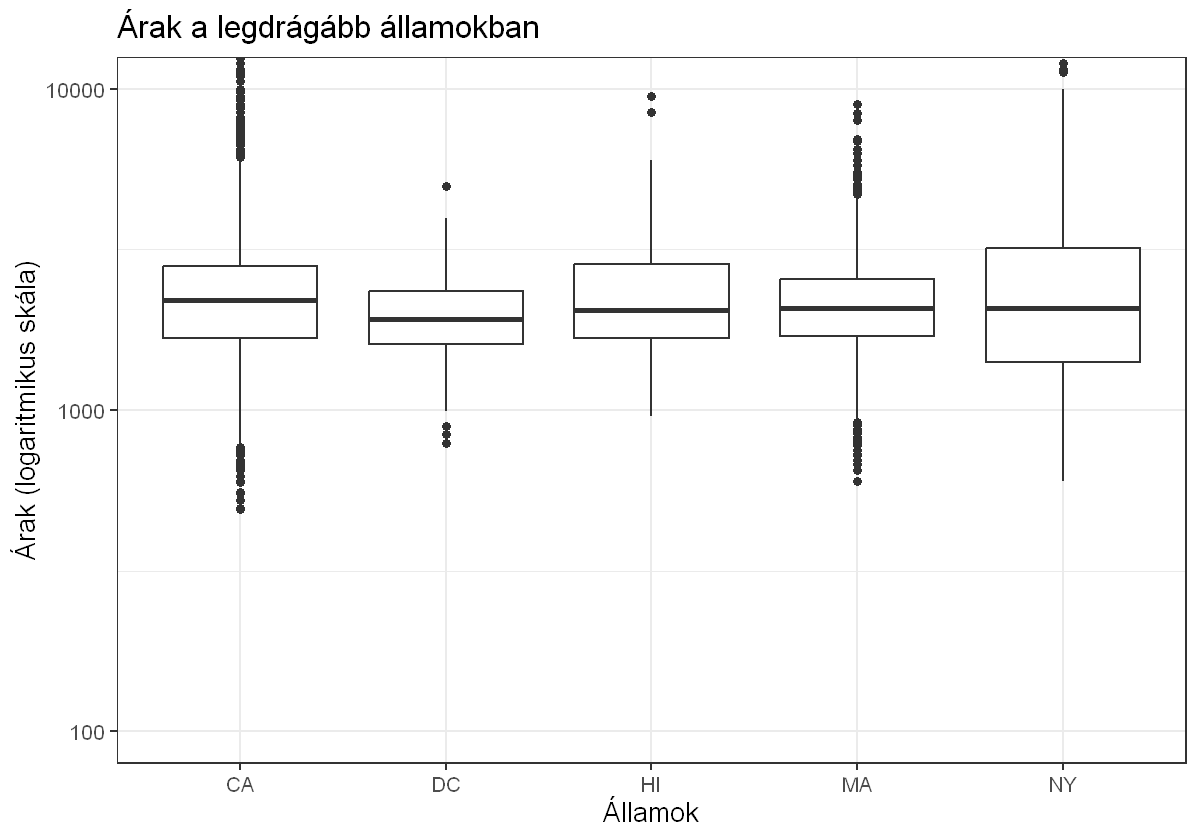

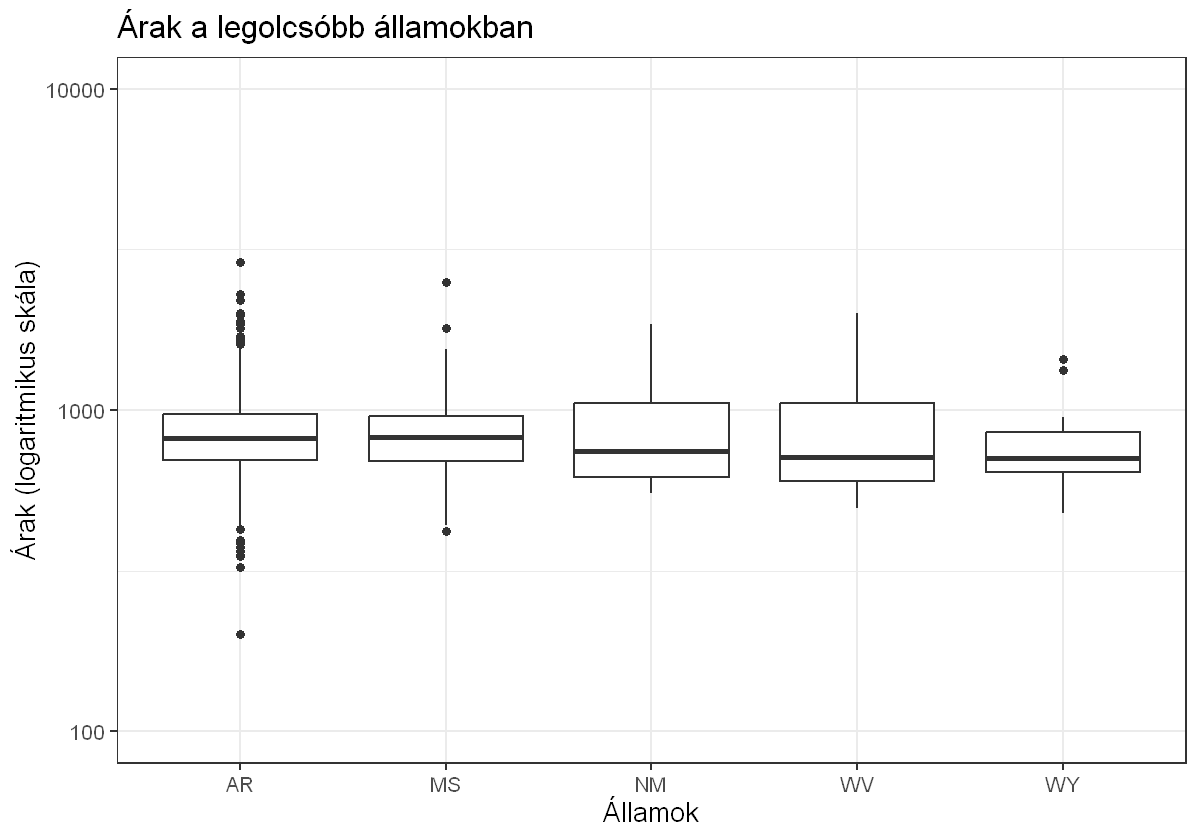

In [123]:
# Árak vizsgálata az egyes államokban (state)

# Magas árú államok
states = dfc %>%
filter(!is.na(state)) %>%
select(price, state) %>%
group_by(state) %>%
summarize(atlag_price = mean(price)) %>%
arrange(desc(atlag_price))

top = head(states$state, 5)

dfc %>%
filter(!is.na(state), state %in% top) %>%
ggplot() + 
geom_boxplot(mapping = aes(x = state, y = price)) +
scale_y_log10() +
coord_cartesian(ylim=c(100, 10000)) +
xlab("Államok") +
ylab("Árak (logaritmikus skála)") +
ggtitle("Árak a legdrágább államokban") + 
theme_bw(base_size = 16)

# Alacsony árú államok
cheap_states = states %>%
arrange(atlag_price)

bot = head(cheap_states$state, 5)

dfc %>%
filter(!is.na(state), state %in% bot) %>%
ggplot() + 
geom_boxplot(mapping = aes(x = state, y = price)) +
scale_y_log10() +
coord_cartesian(ylim=c(100, 10000)) +
xlab("Államok") +
ylab("Árak (logaritmikus skála)") +
ggtitle("Árak a legolcsóbb államokban") + 
theme_bw(base_size = 16)

Konklúzió:    
Jól látható, hogy az egyes államokban mekkora különbség érhető el az árak alapján. California államban az átlag 3500 dollár körül van, míg Wyoming államban csak 900 körül mozog.

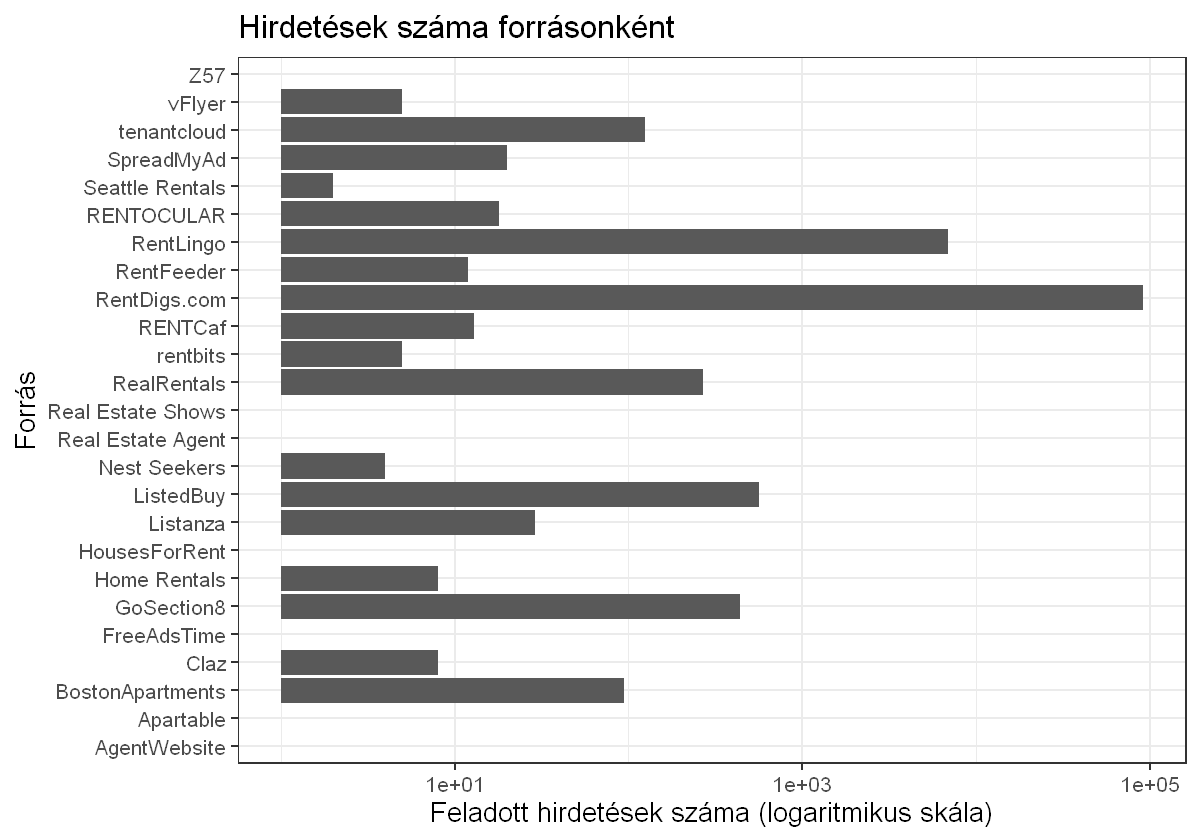

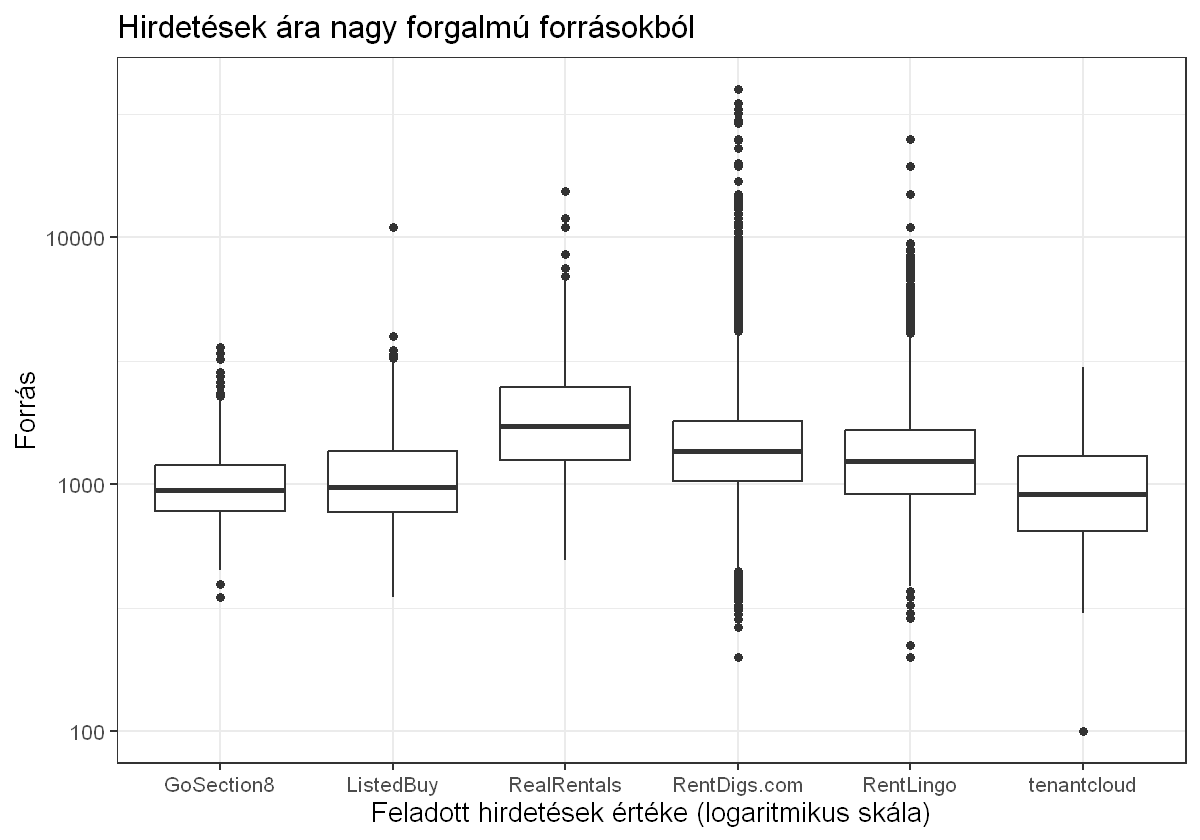

In [124]:
# Források (source) vizsgálata

dfc %>%
filter(!is.na(source)) %>%
select(source) %>%
ggplot() +
geom_bar(mapping = aes(x = source)) +
scale_y_log10() +
xlab("Forrás") +
ylab("Feladott hirdetések száma (logaritmikus skála)") +
ggtitle("Hirdetések száma forrásonként") + 
coord_flip() + 
theme_bw(base_size = 16)

high_traffic = dfc %>%
filter(!is.na(source)) %>%
count(source) %>%
filter(n > 100)

dfc %>%
filter(source %in% high_traffic$source) %>%
select(source, price) %>%
ggplot() +
geom_boxplot(mapping = aes(x = source, y = price)) +
scale_y_log10() +
xlab("Feladott hirdetések értéke (logaritmikus skála)") +
ylab("Forrás") +
ggtitle("Hirdetések ára nagy forgalmú forrásokból") + 
theme_bw(base_size = 16)

Konklúzió:  
A RentDigs.com a messze legtöbb hirdetést feladó oldal, nagyjából 80-90 ezer hirdetéssel, míg a RentLingo második helyen a 10 ezret sem éri el. Meglepő módon azonban az is nagyon jól látható, hogy a RentDigs.com egy meglehetősen magas árkategóriában mozog. Ez vélhetően a kényelmi faktor miatt van, mivel sokan nem látogatnak meg több oldalt, hanem csak a legnépszerűbbet böngészik.

# Modellezés

In [125]:
# Modellezés előkészítése - package

library(tidymodels, warn.conflicts=FALSE)
library(tune, warn.conflicts=FALSE)
library(kknn, warn.conflicts=FALSE)
library(ranger, warn.conflicts=FALSE)

set.seed(17)

In [126]:
# Modellezés előkészítése - adatok

dft = dfc

# Felbontás tanító és tesztelő halmazokra
data_split = initial_split(dft, prop=0.75)

df_train = training(data_split)
df_test  = testing(data_split)

nrow(df_train)/nrow(df)

[1] 0.7495041

### Lineáris regresszió

In [127]:
# Egyszerű modell, benchmarknak

# Recept, minden feature-rel
linear_recept = recipe(price ~ ., data=df_train) %>%
    step_integer(category) %>%
    step_integer(fee) %>%
    step_integer(has_photo) %>%
    step_integer(pets_allowed) %>%
    step_integer(cityname) %>%
    step_integer(state) %>%
    step_integer(source) %>%
    step_integer(washer) %>%
    step_integer(club) %>%
    step_integer(wood_floor) %>%
    step_integer(tv_signal) %>%
    step_integer(dish_washer) %>%
    step_integer(fridge) %>%
    step_integer(playground) %>%
    step_corr(all_numeric_predictors(), threshold = .9) %>%
    prep()

# Tanítás
fit_linear = linear_reg() %>%
set_engine("lm") %>%
set_mode("regression") %>% 
fit(price ~ ., data = bake(linear_recept, df_train))

# Tesztelés
linear_pred = fit_linear %>%
predict(bake(linear_recept, df_test)) %>%
bind_cols(df_test) %>%
select(price, .pred)

In [128]:
# Próbáljuk ki csak a legfontosabb feature-ök használatával is

# Recept, minden feature-rel
linear_2_recept = recipe(price ~ square_feet + bathrooms + bedrooms, data=df_train) %>%
    step_corr(all_numeric_predictors(), threshold = .9) %>%
    prep()

# Tanítás
fit_linear_2 = linear_reg() %>%
set_engine("lm") %>%
set_mode("regression") %>% 
fit(price ~ square_feet + bathrooms + bedrooms, data = bake(linear_2_recept, df_train))

# Tesztelés
linear_2_pred = fit_linear_2 %>%
predict(bake(linear_2_recept, df_test)) %>%
bind_cols(df_test) %>%
select(price, .pred)

In [129]:
# Lineáris regresszió - kiértékelés

lr_pred = tibble(
    mode = c("all features", "few features"),
    rsq  = c(rsq(linear_pred, price, .pred)$.estimate, rsq(linear_2_pred, price, .pred)$.estimate),
    rmse = c(rmse(linear_pred, price, .pred)$.estimate, rmse(linear_2_pred, price, .pred)$.estimate)
)

lr_pred

max_lr_rsq = lr_pred %>%
select(rsq) %>%
arrange(desc(rsq)) %>%
head(1)

min_lr_rmse = lr_pred %>%
select(rmse) %>%
arrange(rmse) %>%
head(1)

mode,rsq,rmse
<chr>,<dbl>,<dbl>
all features,0.2124335,843.7470
few features,0.1619774,866.9561


Konklúzió:  
A lineáris regresszió jobban működött több feature használata esetén, azonban így is maximum 21% pontosságot értünk el, ami nem egy elfogadható eredmény. Mivel gyors betanítása van, és egy egyszerű modell, így nem is vártuk el tőle, hogy jól teljesítsen, de ez még azt az alacsony határt sem éri el, hogy predikciónak lehessen nevezni.

### KNN

In [20]:
# Komplexebb modell, de nem használ factor-okat

knn_mod = 
    nearest_neighbor(neighbors = tune()) %>% 
    set_engine("kknn") %>% 
    set_mode("regression")

# Recept, ahol csak numerikus értékek szerepelnek
# Factor-ok ki vannak hagyva, hogy a távolságoknak legyen értelme,
# és ne legyen felesleges rendeződés az értékeik között
knn_recept =
    recipe(price ~ square_feet + bathrooms + bedrooms + latitude + longitude + time, data=dft) %>%
    step_center(square_feet, bathrooms, bedrooms, latitude, longitude, time) %>%
    step_scale(square_feet, bathrooms, bedrooms, latitude, longitude, time)

cv_splits = vfold_cv(dft)

knn_grid = expand.grid(neighbors=1:30)

# Paraméter tuning
knn_tune = tune_grid(
    knn_mod,
    knn_recept,
    resample=cv_splits,
    grid = knn_grid,
)

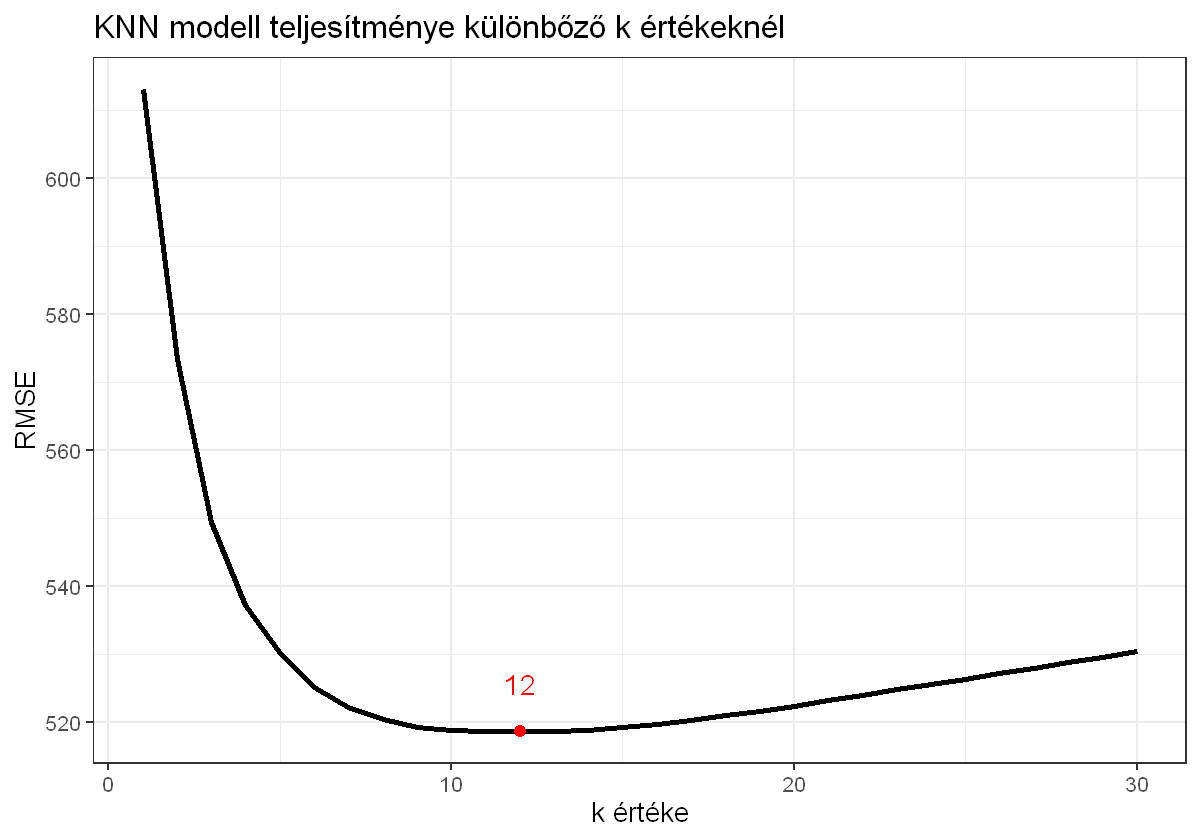

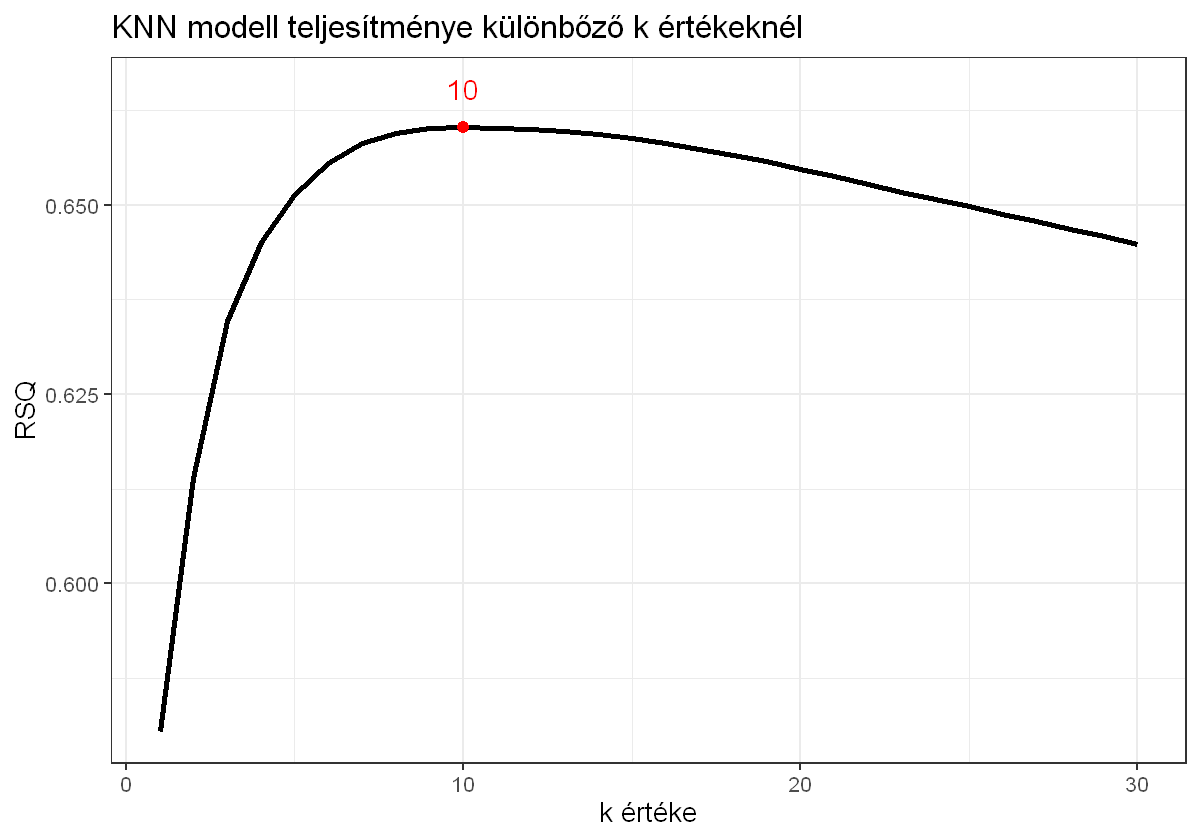

In [130]:
# KNN modell - paraméter tuning kiértékelés

knn_preds = knn_tune %>%
collect_metrics()

min_knn_rmse = knn_preds %>%
filter(.metric=='rmse') %>%
arrange(mean) %>%
head(1)

max_knn_rsq = knn_preds %>%
filter(.metric=='rsq') %>%
arrange(desc(mean)) %>%
head(1)

# Paraméter tuning eredményének kiértékelése
knn_preds %>%
filter(.metric=='rmse') %>%
ggplot() +
geom_line(aes(x = neighbors, y = mean), linewidth = 1.5) + 
annotate("point", x = min_knn_rmse$neighbors, y = min_knn_rmse$mean, colour = "red", size = 3) +
annotate("text", x = min_knn_rmse$neighbors, y = min_knn_rmse$mean+7,
         colour = "red", size = 6, label = min_knn_rmse$neighbors) +
xlab("k értéke") +
ylab("RMSE") +
ggtitle("KNN modell teljesítménye különbőző k értékeknél") + 
theme_bw(base_size = 16)

knn_preds %>%
filter(.metric=='rsq') %>%
ggplot() +
geom_line(aes(x = neighbors, y = mean), linewidth = 1.5) + 
annotate("point", x = max_knn_rsq$neighbors, y = max_knn_rsq$mean, colour = "red", size = 3) +
annotate("text", x = max_knn_rsq$neighbors, y = max_knn_rsq$mean+0.005,
         colour = "red", size = 6, label = max_knn_rsq$neighbors) +
xlab("k értéke") +
ylab("RSQ") +
ggtitle("KNN modell teljesítménye különbőző k értékeknél") + 
theme_bw(base_size = 16)

Konklúzió:  
A KNN modell az esetünkben 10-12 szomszéd vizsgálatával érte el a legjobb teljesítményt, ami egy nagyjából 65%-os pontosság volt. Ezzel még nem mondható rá, hogy sikeresen tud árakat jósolni, de már elfogadhatóan tud közelíteni.

### Random forest

In [26]:
# Modern modell, de sok idő feltanítani

rf_mod = 
    rand_forest(mode = "regression", trees=tune(), mtry=tune()) %>%
    set_engine('ranger')

rf_recept = recipe(price ~ ., data=dft) %>%
    step_integer(category) %>%
    step_integer(fee) %>%
    step_integer(has_photo) %>%
    step_integer(pets_allowed) %>%
    step_integer(cityname) %>%
    step_integer(state) %>%
    step_integer(source) %>%
    step_integer(washer) %>%
    step_integer(club) %>%
    step_integer(wood_floor) %>%
    step_integer(tv_signal) %>%
    step_integer(dish_washer) %>%
    step_integer(fridge) %>%
    step_integer(playground) %>%
    step_corr(all_numeric_predictors(), threshold = .9)

cv_splits = vfold_cv(dft)

rf_grid = expand.grid(trees=c(50,100,200), mtry=c(3,4,5,7,9,13))

# Paraméter tuning
rf_tune = tune_grid(
    rf_mod,
    rf_recept,
    resample = cv_splits,
    grid = rf_grid,
)

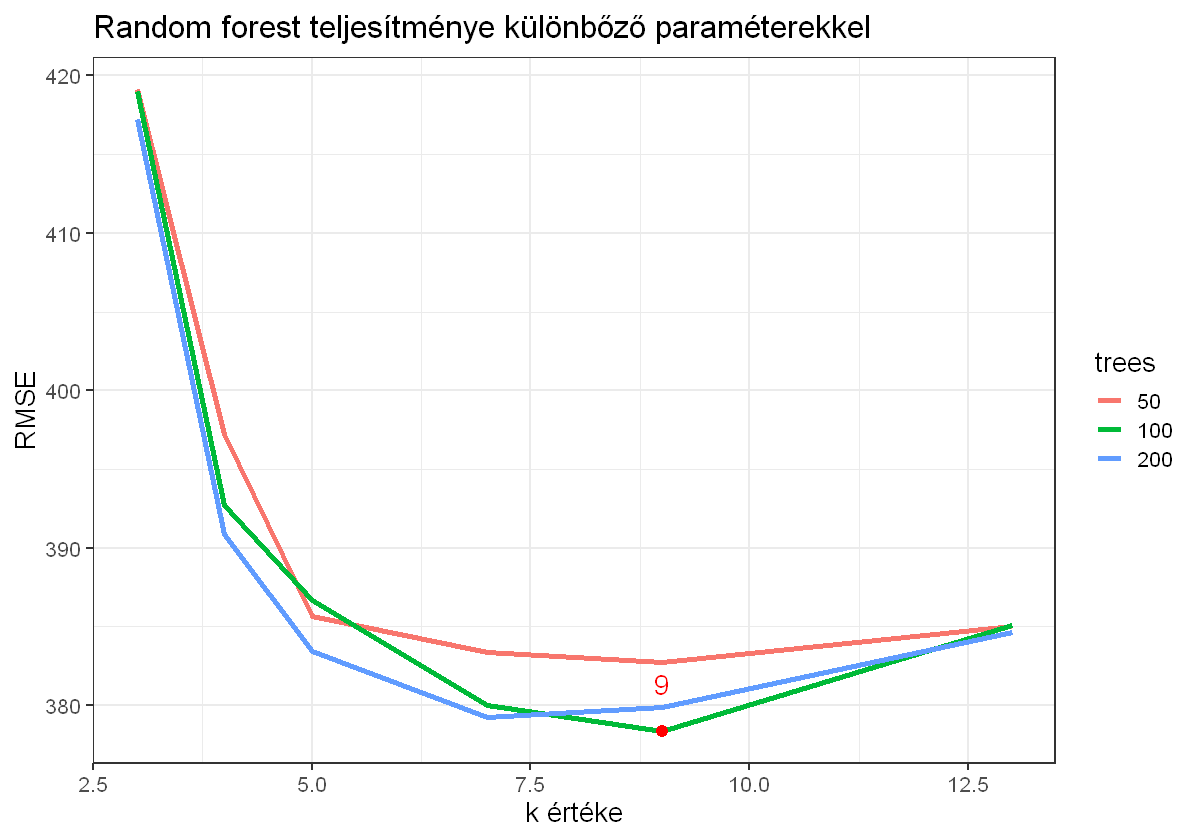

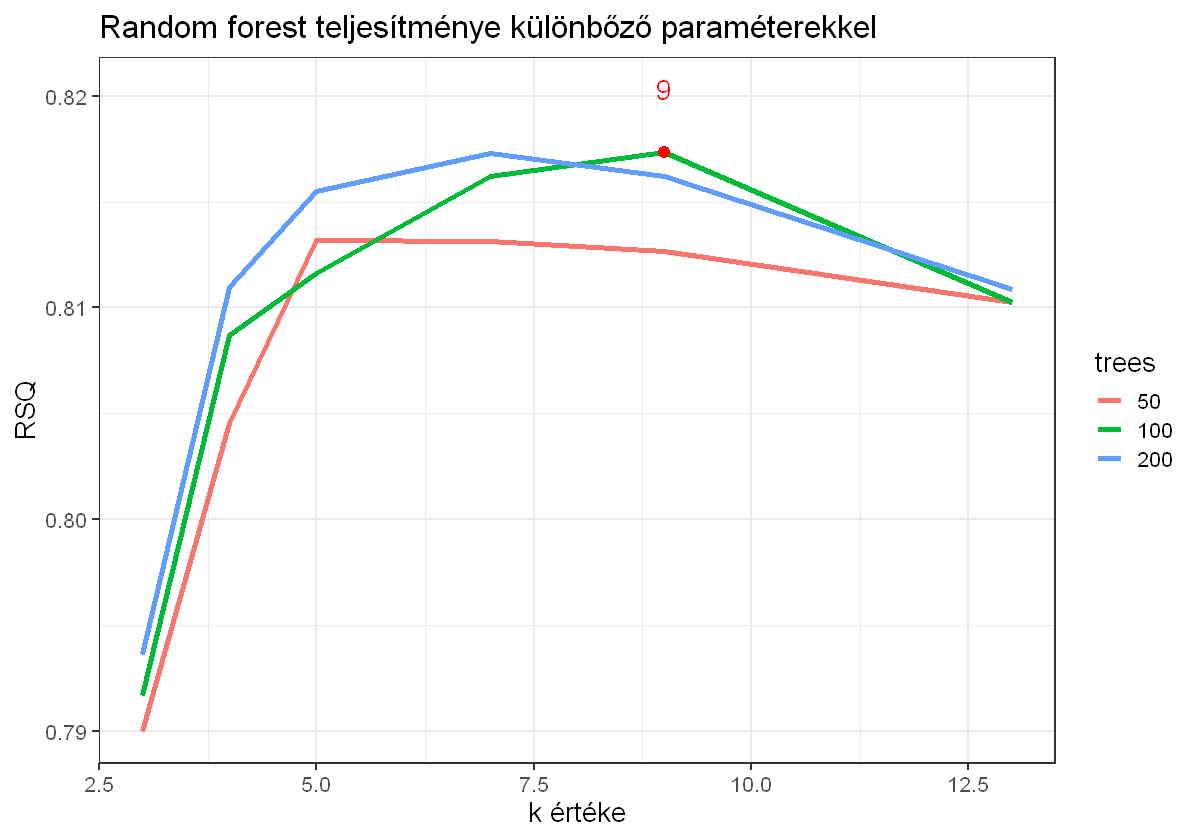

In [131]:
# Random forest modell - paraméter tuning kiértékelés

rf_preds = rf_tune %>%
collect_metrics() %>%
mutate(trees = as.factor(trees))


min_rf_rmse = rf_preds %>%
filter(.metric=='rmse') %>%
arrange(mean) %>%
head(1)

max_rf_rsq = rf_preds %>%
filter(.metric=='rsq') %>%
arrange(desc(mean)) %>%
head(1)

# Paraméter tuning eredményének kiértékelése
rf_preds %>%
filter(.metric=='rmse') %>%
ggplot() +
geom_line(aes(x = mtry, y = mean, color = trees), linewidth = 1.5) + 
annotate("point", x = min_rf_rmse$mtry, y = min_rf_rmse$mean, colour = "red", size = 3) +
annotate("text", x = min_rf_rmse$mtry, y = min_rf_rmse$mean+3,
         colour = "red", size = 6, label = min_rf_rmse$mtry) +
xlab("k értéke") +
ylab("RMSE") +
ggtitle("Random forest teljesítménye különbőző paraméterekkel") + 
theme_bw(base_size = 16)

rf_preds %>%
filter(.metric=='rsq') %>%
ggplot() +
geom_line(aes(x = mtry, y = mean, color = trees), linewidth = 1.5) + 
annotate("point", x = max_rf_rsq$mtry, y = max_rf_rsq$mean, colour = "red", size = 3) +
annotate("text", x = max_rf_rsq$mtry, y = max_rf_rsq$mean+0.003,
         colour = "red", size = 6, label = max_rf_rsq$mtry) +
xlab("k értéke") +
ylab("RSQ") +
ggtitle("Random forest teljesítménye különbőző paraméterekkel") + 
theme_bw(base_size = 16)

Konklúzió:  
Furcsa módon a több fa használata nem eredményezett jobb teljesítményt, azonban jól látszik, hogy kevesebb feature használatával volt képes jó predikciókat adni.
A feltanítási idő meglehetősen hosszú volt, de a 81%-os pontosságot meghaladtuk, így sikeresnek könyvelhető el a modell.

### Modell összehasonlítás

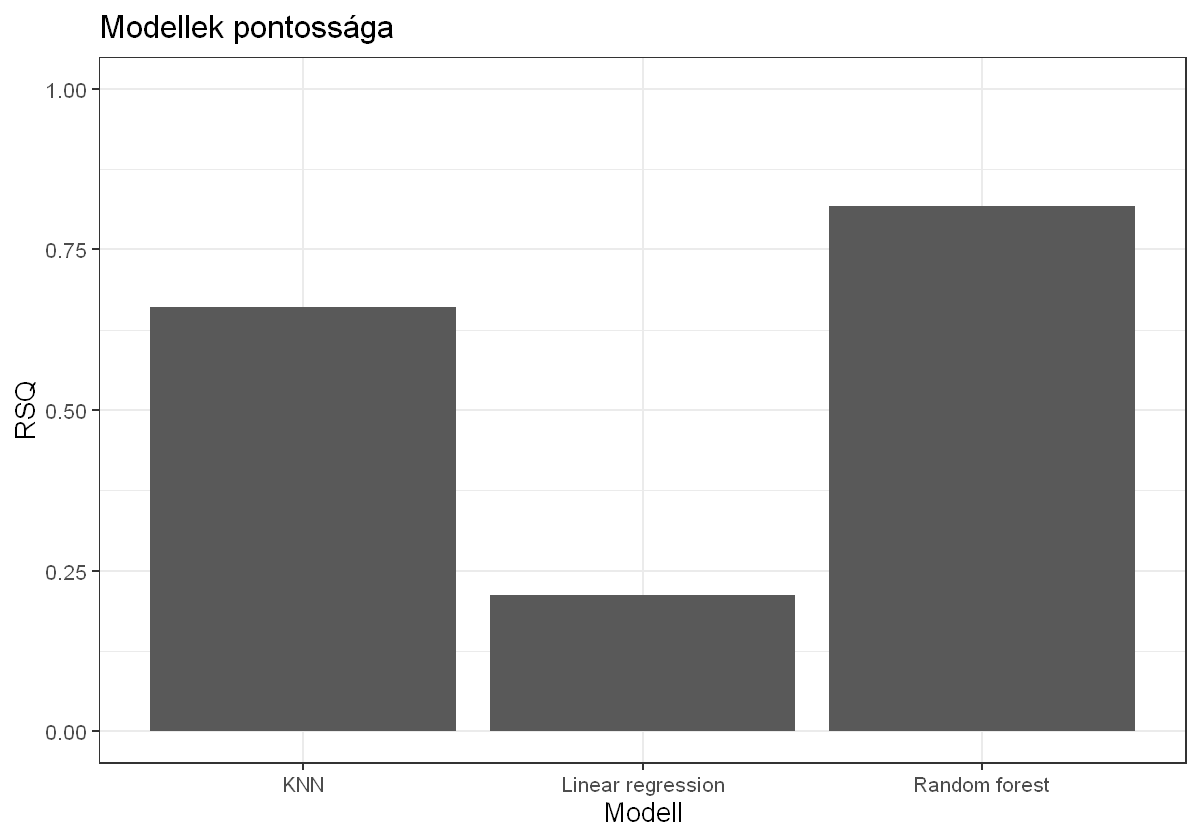

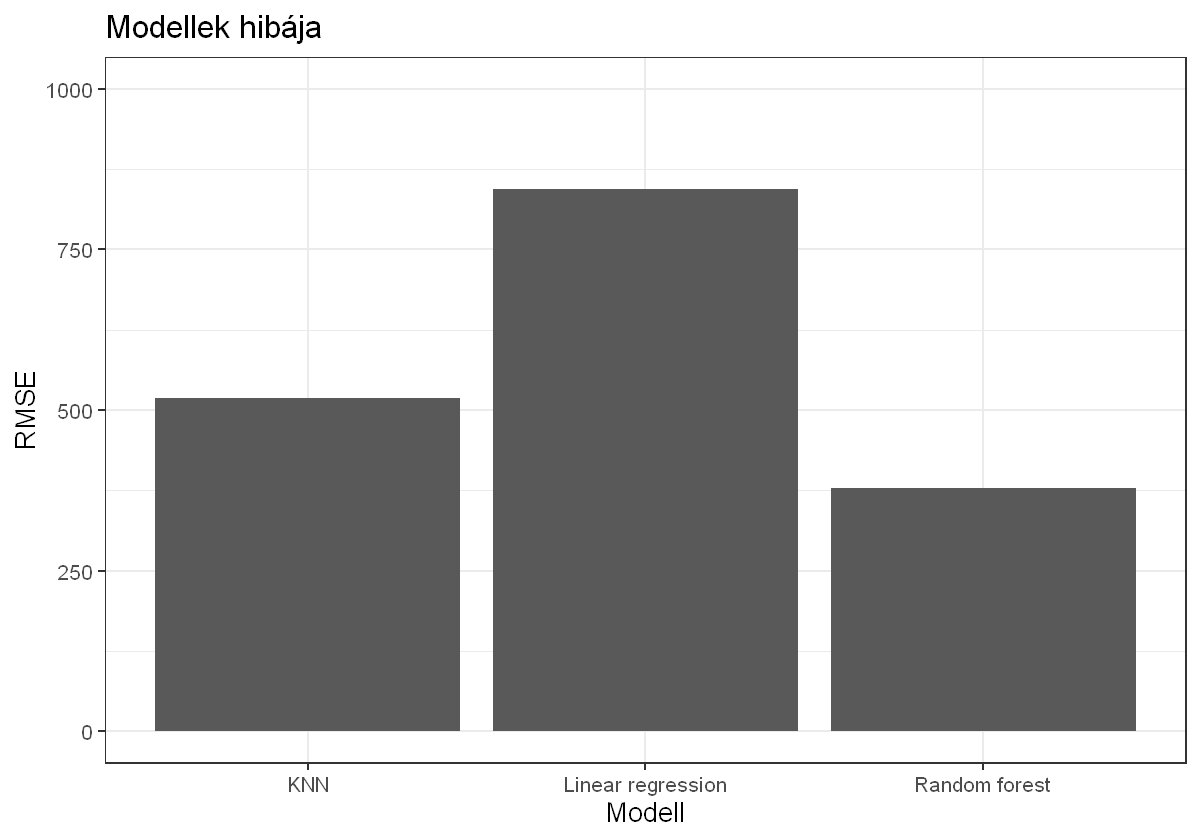

In [132]:
#Eredmények táblázatba foglalása
models = tibble(
    model = c("Linear regression", "KNN", "Random forest"),
    rsq   = c(max_lr_rsq$rsq, max_knn_rsq$mean, max_rf_rsq$mean), 
    rmse  = c(min_lr_rmse$rmse, min_knn_rmse$mean, min_rf_rmse$mean)
)

models %>%
ggplot() +
geom_col(mapping = aes(x = model, y = rsq)) +
coord_cartesian(ylim=c(0, 1)) +
xlab("Modell") +
ylab("RSQ") +
ggtitle("Modellek pontossága") + 
theme_bw(base_size = 16)

models %>%
ggplot() +
geom_col(mapping = aes(x = model, y = rmse)) +
coord_cartesian(ylim=c(0, 1000)) +
xlab("Modell") +
ylab("RMSE") +
ggtitle("Modellek hibája") + 
theme_bw(base_size = 16)

Konklúzió:  
A lineáris regresszió esetünkben egy nagyon rossz pontosságot adó modell, de nagyon gyorsan tanítható.
A KNN és random forest modellek között is van egy ugrás teljesítményben, azonban ezt a betanítási idő ellensúlyozza.

# Összegzés

A modellek használatával sikeresen elértünk egy 80% feletti pontossági rátát, és ezzel elmondhatjuk, hogy elég jól meg tudjuk becsülni az ingatlan értékét a megkapott paraméterek segítségével.  
Jól láthatóan megmutattuk a gyorsabb, de egyszerűbb, valamint a lassabb, de modernebb és komplexebb modellek közti teljesítmény-beli különbségeket is.